In [3]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import ollama
import matplotlib.pyplot as plt
import squarify 

In [4]:
class LikertSurvey:
    def __init__(self, n_questions, csv_path="USSF Likert Survey Questions.csv", randomize_responses=False, prompt_user=False):
        self.csv_path = csv_path
        self.randomize_responses = randomize_responses
        self.prompt_user = prompt_user
        self.n_questions = n_questions
        self.survey = []

        assert self.randomize_responses or self.prompt_user, "At least one of randomize_responses or prompt_user must be True"
        assert self.n_questions <= 100, "n_questions must be less than or equal to the number of questions in the survey"   

        self._load_questions()

    def _load_questions(self):
        try:
            df = pd.read_csv(self.csv_path)
        except FileNotFoundError:
            print(f"File not found: {self.csv_path}")
            return []
        
        survey = []
        for _, row in df.iterrows():
            question_tuple = (row['Statement'], None)
            if self.prompt_user:
                question_tuple = (row['Statement'], self._ask_question(row['Statement']))
            elif self.randomize_responses:
                question_tuple = (row['Statement'], np.random.randint(1, 6))
            
            if question_tuple[1] is not None:
                survey.append(question_tuple)
                if len(survey) >= self.n_questions:
                    break         
        self.survey = survey
        return self.survey


    def _ask_question(self, question):
        print(question)
        response = input("Enter your response 1-5 (1 being strongly disagree, 5 being strongly agree): ")
        if response not in ['1', '2', '3', '4', '5']:
            print("Please enter a number between 1 and 5.")
            return self.prompt_user(question)
        return int(response)

    def get_survey(self):
        return self.survey    

In [5]:
guardianRandomResponse = LikertSurvey(n_questions=15, randomize_responses=True)
guardianRandomResponse.get_survey()

[('My work contributes meaningfully to national security.', 4),
 ('I am satisfied with my current duty location.', 2),
 ('The USSF provides clear career progression paths.', 3),
 ("The USSF's technology and equipment are adequate for mission success.", 5),
 ('The USSF provides adequate recognition for achievements.', 5),
 ('I have adequate access to continuing education opportunities.', 1),
 ('My unit maintains high standards of performance.', 4),
 ('My supervisor provides helpful feedback on my performance.', 5),
 ('The USSF effectively manages workload distribution.', 4),
 ('The USSF supports my personal and family needs.', 3),
 ('The USSF provides clear guidance on professional conduct.', 2),
 ('The USSF provides clear expectations for performance.', 5),
 ('The USSF effectively communicates its achievements to the public.', 2),
 ('The USSF provides adequate financial planning resources.', 5),
 ('The USSF provides adequate opportunities for joint assignments.', 1)]

In [6]:
# Monte Carlo Simulation of 1000 Randomized Surveys with all 100 Questions 
survey_list = []
for i in tqdm(range(10_000)):
    guardian = LikertSurvey(n_questions=100, randomize_responses=True)
    survey = guardian.get_survey()
    survey_list.append(survey)

# Convert the list of surveys into a DataFrame
# Each unique question should be a column where each row is a sample
unique_questions = set(item[0] for sublist in survey_list for item in sublist)
df_dict = {question: [] for question in unique_questions}

for survey in survey_list:
    survey_dict = {question: None for question in unique_questions}
    for question, response in survey:
        survey_dict[question] = response
    for question in unique_questions:
        df_dict[question].append(survey_dict[question])

df = pd.DataFrame(df_dict)

100%|██████████| 10000/10000 [00:52<00:00, 191.58it/s]


In [7]:
df.head()

,The USSF effectively balances tradition with innovation.,I understand the USSF's mission and my role in it.,The USSF effectively utilizes my skills and abilities.,I feel connected to the USSF's vision for the future.,I am satisfied with the USSF uniform and appearance standards.,My work contributes meaningfully to national security.,I understand how my role contributes to the larger USSF mission.,I have access to the resources needed to perform my job effectively.,My work environment is positive and supportive.,The USSF values innovation and new ideas.,...,I feel my career field is valued within the USSF.,The USSF provides adequate family support services.,I feel the USSF offers competitive career opportunities compared to civilian space sector.,The USSF effectively integrates with other military branches.,I am satisfied with my current duty location.,I have confidence in my peers' abilities.,I have adequate opportunities for operational experience.,The USSF's technology and equipment are adequate for mission success.,I am satisfied with the USSF's leave policies.,I have adequate opportunities to network with industry professionals.
0,3,2,2,1,2,4,1,1,5,2,...,2,5,4,2,1,3,3,4,2,4
1,1,3,1,1,5,1,3,1,4,5,...,2,2,4,4,5,1,2,4,2,5
2,2,3,1,1,4,1,1,5,2,3,...,3,5,1,4,4,2,1,2,5,4
3,3,1,2,2,3,2,5,4,3,3,...,4,2,2,3,3,1,5,5,1,2
4,3,2,5,4,2,4,5,5,5,4,...,2,2,5,3,2,3,1,3,2,1


In [8]:
# Transpose the DataFrame so that headers of the original df become rows in column 1
survey_analytics = df.describe().transpose().reset_index()
survey_analytics = survey_analytics.drop(columns=['count', 'min', 'max','25%','50%','75%'])
survey_analytics.head()

,index,mean,std
0,The USSF effectively balances tradition with i...,3.0142,1.424500
1,I understand the USSF's mission and my role in...,3.0247,1.403242
2,The USSF effectively utilizes my skills and ab...,3.0002,1.403138
3,I feel connected to the USSF's vision for the ...,2.9884,1.399879
4,I am satisfied with the USSF uniform and appea...,2.9999,1.412622


In [9]:
# pre-process the original df, map 1-5 to 0-1 decimal
df = df.applymap(lambda x: {1: 0, 2: 0.25, 3: 0.5, 4: 0.75, 5: 1}.get(x, x))
df.head()

C:\Users\17276\AppData\Local\Temp\ipykernel_14844\2616968039.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: {1: 0, 2: 0.25, 3: 0.5, 4: 0.75, 5: 1}.get(x, x))


,The USSF effectively balances tradition with innovation.,I understand the USSF's mission and my role in it.,The USSF effectively utilizes my skills and abilities.,I feel connected to the USSF's vision for the future.,I am satisfied with the USSF uniform and appearance standards.,My work contributes meaningfully to national security.,I understand how my role contributes to the larger USSF mission.,I have access to the resources needed to perform my job effectively.,My work environment is positive and supportive.,The USSF values innovation and new ideas.,...,I feel my career field is valued within the USSF.,The USSF provides adequate family support services.,I feel the USSF offers competitive career opportunities compared to civilian space sector.,The USSF effectively integrates with other military branches.,I am satisfied with my current duty location.,I have confidence in my peers' abilities.,I have adequate opportunities for operational experience.,The USSF's technology and equipment are adequate for mission success.,I am satisfied with the USSF's leave policies.,I have adequate opportunities to network with industry professionals.
0,0.50,0.25,0.25,0.00,0.25,0.75,0.0,0.00,1.00,0.25,...,0.25,1.00,0.75,0.25,0.00,0.50,0.50,0.75,0.25,0.75
1,0.00,0.50,0.00,0.00,1.00,0.00,0.5,0.00,0.75,1.00,...,0.25,0.25,0.75,0.75,1.00,0.00,0.25,0.75,0.25,1.00
2,0.25,0.50,0.00,0.00,0.75,0.00,0.0,1.00,0.25,0.50,...,0.50,1.00,0.00,0.75,0.75,0.25,0.00,0.25,1.00,0.75
3,0.50,0.00,0.25,0.25,0.50,0.25,1.0,0.75,0.50,0.50,...,0.75,0.25,0.25,0.50,0.50,0.00,1.00,1.00,0.00,0.25
4,0.50,0.25,1.00,0.75,0.25,0.75,1.0,1.00,1.00,0.75,...,0.25,0.25,1.00,0.50,0.25,0.50,0.00,0.50,0.25,0.00


In [10]:
# Train a Logistic Regression Model 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Generate a random target Variable
df['STATUS'] = np.random.choice([0, 1], size=len(df), p=[0.75, 0.25])

# Split the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(df, df['STATUS'], test_size=0.3, random_state=42)
X_train = X_train.drop(columns=['STATUS'])
X_test = X_test.drop(columns=['STATUS'])

# Train a Logistic Regression Model
model = LogisticRegression(max_iter=200)  # Increase max_iter to avoid convergence warnings

# Re-train the Logistic Regression Model with corrected features
model.fit(X_train, y_train)

# Make predictions on the test set with corrected features
y_pred = model.predict(X_test)

# Evaluate the model with corrected features
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=1)  # Handle zero division in classification report

# Print the corrected accuracy and report
print(accuracy)
print(report)

0.762
              precision    recall  f1-score   support

           0       0.76      1.00      0.86      2286
           1       1.00      0.00      0.00       714

    accuracy                           0.76      3000
   macro avg       0.88      0.50      0.43      3000
weighted avg       0.82      0.76      0.66      3000



In [11]:
# Check if the implementation correctly identifies the top 10 most important features
feature_names = X_train.columns
coefficients = model.coef_[0]  

# Create a DataFrame to hold feature names and their corresponding coefficients
feature_importance = pd.DataFrame({
    'Question': feature_names,
    'Weight': coefficients
})

feature_importance = feature_importance.reindex(feature_importance.Weight.abs().sort_values(ascending=False).index)
print(feature_importance)

                                             Question    Weight
96  I have adequate opportunities for operational ... -0.246218
83  The USSF offers adequate specialized training ... -0.203222
14  My compensation is competitive with civilian a...  0.191010
88  The USSF provides adequate recognition for ach...  0.172349
49  The USSF effectively manages workload distribu...  0.169503
..                                                ...       ...
31   My unit maintains high standards of performance. -0.009061
75  The USSF effectively manages personnel assignm...  0.008341
38  I have adequate opportunities to participate i...  0.008008
82  I feel prepared for future challenges in space...  0.007632
20  I feel the USSF is adequately funded for its m... -0.005176

[100 rows x 2 columns]


In [12]:
def embed_text_local(text):
    response = ollama.embed(
        model="nomic-embed-text",
        input=text,
    )
    return response.embeddings[0]

feature_importance['embedding'] = None  
for index, row in tqdm(feature_importance.iterrows(), total=feature_importance.shape[0]):
    embedding_vector = embed_text_local(row['Question'])
    feature_importance.at[index, 'embedding'] = embedding_vector

100%|██████████| 100/100 [00:05<00:00, 19.99it/s]


In [29]:
# apply clustering to the embeddings to find 5 clusters
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=9, random_state=42)

# Fit the KMeans model to the embeddings
kmeans.fit(np.vstack(feature_importance['embedding'].values))

# Add the cluster labels to the feature_importance DataFrame
feature_importance['cluster'] = kmeans.labels_

# For each Cluster Print the top 5 Questions
for cluster in range(9):
    print(f"Group {cluster+1}:")
    top_questions = feature_importance[feature_importance['cluster'] == cluster].sort_values(by='Weight', ascending=False)
    for _, row in top_questions.iterrows():
        if row['Weight'] > 0:
            print(f"\t {row['Weight']:.2f} \t {row['Question']} ")
        else:
            print(f"\t{row['Weight']:.2f} \t {row['Question']} ")
    print("\n")

Group 1:
	 0.19 	 My compensation is competitive with civilian alternatives. 
	 0.16 	 I am satisfied with promotion opportunities in the USSF. 
	 0.12 	 I am proud to serve in the USSF. 
	 0.08 	 I feel my career field is valued within the USSF. 
	 0.07 	 I feel valued as a member of the USSF. 
	 0.07 	 I feel the USSF is at the cutting edge of space operations. 
	 0.06 	 I understand how my role contributes to the larger USSF mission. 
	 0.05 	 I feel the USSF is prepared for future space threats. 
	-0.01 	 The USSF effectively utilizes my skills and abilities. 
	-0.05 	 The USSF provides a sense of purpose in my professional life. 
	-0.07 	 I feel the USSF is respected by other military branches. 
	-0.08 	 I feel the USSF values work-life balance. 
	-0.14 	 I feel connected to the USSF's vision for the future. 
	-0.16 	 I understand the USSF's mission and my role in it. 


Group 2:
	 0.17 	 The USSF provides adequate recognition for achievements. 
	 0.05 	 I feel the USSF offers com

C:\Users\17276\AppData\Local\Temp\ipykernel_14844\3227017876.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simplified_feature_importance['color'] = simplified_feature_importance['Weight'].apply(lambda x: (1, 0, 0) if x < 0 else (0, 1, 0))
C:\Users\17276\AppData\Local\Temp\ipykernel_14844\3227017876.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simplified_feature_importance['color'] = simplified_feature_importance['Weight'].apply(lambda x: (1, 0, 0) if x < 0 else (0, 1, 0))
C:\Users\17276\AppDa

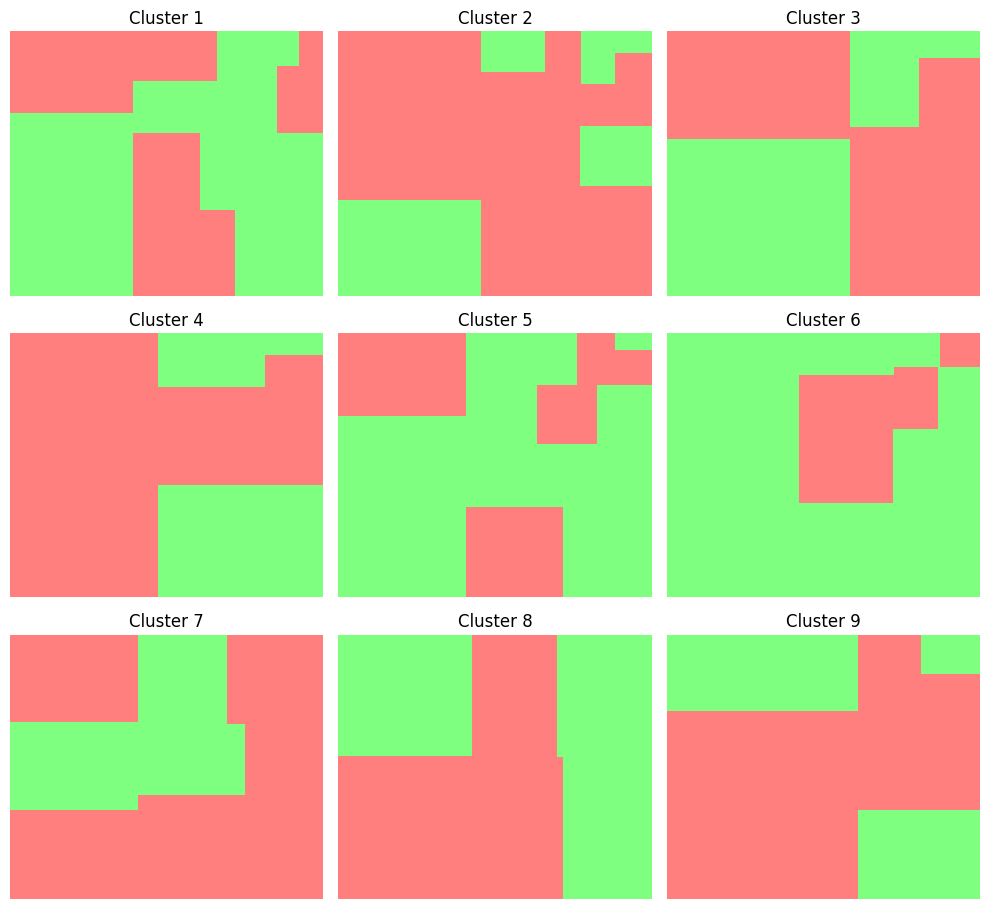

In [31]:

# Set up the figure for subplots with 2 rows and 4 columns
fig, axes = plt.subplots(3, 3, figsize=(10, 10))  # Adjusted figsize to better fit two rows

# Generate a treemap plot for each cluster
for cluster in range(9):   
    # Filter the questions belonging to the current cluster
    cluster_data = feature_importance[feature_importance['cluster'] == cluster]
    
    # Prepare the data for plotting
    simplified_feature_importance = cluster_data[['Question', 'Weight']]
    simplified_feature_importance['color'] = simplified_feature_importance['Weight'].apply(lambda x: (1, 0, 0) if x < 0 else (0, 1, 0))
    
    # Normalize the weights to ensure the image size is manageable
    normalized_weights = simplified_feature_importance['Weight'].abs()
    
    # Determine the subplot position
    ax = axes[cluster // 3, cluster % 3]  # Use integer division and modulus to map cluster to subplot

    # Plot the treemap in the corresponding subplot
    squarify.plot(
        sizes=normalized_weights, 
        color=simplified_feature_importance['color'], 
        alpha=0.5,
        ax=ax
    )
    ax.set_title(f"Cluster {cluster+1}")
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
